# ClimateGuard AI v3.0 - Explainable AI (SHAP) 

This notebook covers model explanation using SHAP values. 

## 1. Import Libraries  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib
import warnings

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

# Disable numba for SHAP to avoid DLL issues
os.environ["SHAP_USE_NUMBA"] = "0"
os.environ["NUMBA_DISABLE_JIT"] = "1"

# Import SHAP with error handling
try:
    import shap  # noqa: F401
except ImportError as e:
    err_msg = str(e).lower()
    if "dispatcher" in err_msg or "numba" in err_msg or "llvmlite" in err_msg:
        print("SHAP import hit a numba/llvmlite DLL issue; numba already disabled.")
        print(f"Error details: {e}")
        print("SHAP import hit a numba/llvmlite DLL issue; numba already disabled.")
        print(f"Error details: {e}")
        try:
            import shap  # noqa: F401
        except ImportError as e2:
            print("Retrying SHAP import failed; SHAP explainability will be disabled.")
            print(f"Error details: {e2}")
            shap = None
        else:
            pass

# Import ModelExplainer (adapter chooses SHAP or sklearn fallback)
try:
    from src.explainability.explainable import ModelExplainer
except ImportError as e:
    print(f"Warning: Could not import ModelExplainer adapter: {e}")
    print("ModelExplainer will not be available for this session.")
    ModelExplainer = None

# Ensure plots are displayed inline
%matplotlib inline

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Trained Model and Data 

In [2]:
# Load the trained rainfall model (try multiple locations)
rainfall_model = None
possible_paths = [
    os.path.join('..', 'trained_models', 'rainfall_model.pkl'),
    os.path.join('trained_models', 'rainfall_model.pkl'),
    os.path.join(os.getcwd(), 'trained_models', 'rainfall_model.pkl')
]

for p in possible_paths:
    try:
        if os.path.exists(p):
            rainfall_model = joblib.load(p)
            print(f"Rainfall model loaded from {p}")
            break
    except Exception as e:
        print(f"Failed to load rainfall model from {p}: {e}")

if rainfall_model is None:
    print("Warning: `rainfall_model` not found; explanations will use fallback or dummy explainer")

# Load the data from anomaly detection step
df = pd.read_csv('../data/processed/10_anomaly_detection.csv')
print(f"Data loaded: {df.shape}")

Rainfall model loaded from ..\trained_models\rainfall_model.pkl
Data loaded: (119398, 80)


## 3. Prepare Features for Explanation

In [3]:
# Select numerical features (same as used in training)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numerical_cols if 'climate_zone' not in col and 'rain_target' not in col and 'heatwave_target' not in col and 'is_anomaly' not in col and 'anomaly_score' not in col and 'overall_score' not in col and 'category' not in col and 'color' not in col and 'weights_used' not in col]

X = df[feature_cols].fillna(0)

# Create target (rainfall)
if 'precipitation' in df.columns:
    y = (df['precipitation'] > 0).astype(int)
else:
    y = None

print(f"Features: {len(X.columns)}")
print(f"Samples: {len(X)}")

Features: 49
Samples: 119398


## 4. Initialize Model Explainer

In [4]:
if ModelExplainer is None:
    # Fallback dummy explainer so the notebook can run without SHAP.
    class ModelExplainer:
        def __init__(self, model, data, feature_names=None):
            self.model = model
            self.X = data
            self.feature_names = feature_names or list(data.columns)
            self.preprocessed = False

        def preprocess_data(self):
            # no real preprocessing without SHAP
            self.preprocessed = True

        def create_tree_explainer(self):
            # no-op fallback
            return None

        def calculate_shap_values(self, max_samples=100):
            # return a zero array shaped (n_samples, n_features) as a placeholder
            n = min(max_samples, len(self.X))
            return np.zeros((n, len(self.feature_names)))

        def get_feature_importance(self):
            # zero importance for all features
            return {f: 0.0 for f in self.feature_names}

        def plot_summary_plot(self, save_path=None):
            plt.figure(figsize=(6, 3))
            plt.text(0.5, 0.5, "SHAP unavailable - summary plot placeholder", ha="center")
            plt.axis("off")
            if save_path:
                plt.savefig(save_path, bbox_inches="tight", dpi=150)
            # Removed plt.close() to allow inline display

        def plot_bar_plot(self, save_path=None):
            plt.figure(figsize=(6, 3))
            plt.text(0.5, 0.5, "SHAP unavailable - bar plot placeholder", ha="center")
            plt.axis("off")
            if save_path:
                plt.savefig(save_path, bbox_inches="tight", dpi=150)
            # Removed plt.close() to allow inline display

        def plot_waterfall_plot(self, instance_idx=0, save_path=None):
            plt.figure(figsize=(6, 3))
            plt.text(0.5, 0.5, "SHAP unavailable - waterfall placeholder", ha="center")
            plt.axis("off")
            if save_path:
                plt.savefig(save_path, bbox_inches="tight", dpi=150)
            # Removed plt.close() to allow inline display

        def plot_decision_plot(self, instance_idx=0, save_path=None):
            plt.figure(figsize=(6, 3))
            plt.text(0.5, 0.5, "SHAP unavailable - decision plot placeholder", ha="center")
            plt.axis("off")
            if save_path:
                plt.savefig(save_path, bbox_inches="tight", dpi=150)
            # Removed plt.close() to allow inline display

        def explain_instance(self, sample):
            # safe prediction handling for single-row dataframe
            try:
                X_sample = sample[self.feature_names]
            except Exception:
                X_sample = sample
            pred = None
            try:
                if hasattr(self.model, "predict_proba"):
                    pred = float(self.model.predict_proba(X_sample)[:, 1].mean())
                else:
                    pred = float(self.model.predict(X_sample).mean())
            except Exception:
                pred = float(np.nan)
            contributions = {f: {"shap_value": 0.0, "impact": "neutral"} for f in self.feature_names}
            return {"base_value": 0.0, "prediction": pred, "feature_contributions": contributions}

        def generate_explanation_report(self):
            return {"status": "SHAP unavailable", "features": self.feature_names}

        def print_report(self):
            print("SHAP is not installed or ModelExplainer could not be imported. Using fallback dummy explainer.")

explainer = ModelExplainer(rainfall_model, X, feature_names=feature_cols)
print("Model explainer initialized")
print("Model explainer initialized")

INFO:src.explainability.explainable:Using sklearn-based ModelExplainer (fallback)


Model explainer initialized
Model explainer initialized


## 5. Preprocess Data

In [5]:
explainer.preprocess_data()
print("Data preprocessed and scaled")

INFO:src.explainability.model_explainer:Data preprocessed and scaled


Data preprocessed and scaled


## 6. Create Tree Explainer

In [6]:
shap_lib = globals().get("shap", None)

try:
    explainer.create_tree_explainer()
except Exception as exc:
    msg = str(exc).lower()
    if "treeexplainer" in msg and "not yet supported" in msg:
        if hasattr(explainer, "create_linear_explainer"):
            explainer.create_linear_explainer()
        elif shap_lib is not None and hasattr(shap_lib, "LinearExplainer"):
            input_features = getattr(rainfall_model, "feature_names_in_", None)
            explainer_data = X.loc[:, input_features] if input_features is not None else X.copy()

            expected_features = getattr(rainfall_model, "n_features_in_", None)
            if expected_features is not None and explainer_data.shape[1] != expected_features:
                explainer_data = explainer_data.iloc[:, :expected_features]
                print(f"Adjusted explainer data to {expected_features} features to match model input.")

            explainer.explainer = shap_lib.LinearExplainer(
                rainfall_model,
                explainer_data,
                feature_names=explainer_data.columns.tolist(),
            )
        else:
            print("SHAP TreeExplainer is not supported for this model type and no LinearExplainer is available.")
    else:
        raise
print("Tree explainer created")
print("Tree explainer created")

Tree explainer created
Tree explainer created


## 7. Calculate SHAP Values

In [7]:
def calculate_shap_values(self, X_test=None, max_samples=100):
    """
    Calculate SHAP values for the trained model.

    Parameters
    ----------
    X_test : pd.DataFrame or np.ndarray, optional
        Data to explain. If None, uses self.X.
    max_samples : int
        Maximum number of samples for SHAP.

    Returns
    -------
    np.ndarray or list
        SHAP values.
    """

    if self.explainer is None:
        raise ValueError("SHAP explainer has not been initialized.")

    # Use stored data if no input is provided
    if X_test is None:
        if hasattr(self, "X") and self.X is not None:
            X_test = self.X
        else:
            raise ValueError("No input data available for SHAP explanation.")

    # Convert numpy array to DataFrame if necessary
    if isinstance(X_test, np.ndarray):
        if hasattr(self.model, "feature_names_in_"):
            X_test = pd.DataFrame(
                X_test,
                columns=self.model.feature_names_in_
            )
        else:
            X_test = pd.DataFrame(X_test)

    # Ensure DataFrame
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test)

    # Keep only the features used during model training
    if hasattr(self.model, "feature_names_in_"):
        trained_features = list(self.model.feature_names_in_)

        missing_cols = [
            col for col in trained_features
            if col not in X_test.columns
        ]

        if missing_cols:
            raise ValueError(
                f"Missing required features for SHAP: {missing_cols}"
            )

        X_test = X_test[trained_features]

    # Fill missing values
    X_test = X_test.fillna(0)

    # Scale if scaler exists
    if hasattr(self, "scaler") and self.scaler is not None:
        X_to_explain = self.scaler.transform(X_test)
    else:
        X_to_explain = X_test.values

    # Limit sample size
    X_to_explain = X_to_explain[:max_samples]

    # Calculate SHAP
    self.shap_values = self.explainer.shap_values(X_to_explain)

    return self.shap_values

In [8]:
# print("Calculating SHAP values...")
# print("Calculating SHAP values...")
# if hasattr(explainer, "X"):
#     explainer.X = explainer_data

# try:
#     shap_values = explainer.calculate_shap_values(max_samples=100, data=explainer_data)
# except TypeError:
#     print("Calculating SHAP values...")

#     if hasattr(explainer, "X"):
#         explainer.X = explainer_data

#     if hasattr(explainer, "feature_names"):
#         explainer.feature_names = explainer_data.columns.tolist()

#     if hasattr(explainer, "explainer") and hasattr(explainer.explainer, "feature_names"):
#         explainer.explainer.feature_names = explainer_data.columns.tolist()

#     try:
#         shap_values = explainer.calculate_shap_values(max_samples=100, data=explainer_data)
#     except TypeError:
#         try:
#             shap_values = explainer.calculate_shap_values(max_samples=100, data=explainer_data)
#         except (TypeError, ValueError):
#             print("Calculating SHAP values...")

#             if hasattr(explainer, "X"):
#                 explainer.X = explainer_data

#             if hasattr(explainer, "feature_names"):
#                 explainer.feature_names = explainer_data.columns.tolist()

#             if hasattr(explainer, "explainer") and hasattr(explainer.explainer, "feature_names"):
#                 explainer.explainer.feature_names = explainer_data.columns.tolist()

#             shap_values = explainer.calculate_shap_values(max_samples=100)

#         print(f"SHAP values calculated for {shap_values.shape[0] if hasattr(shap_values, 'shape') else len(shap_values)} samples")

#     print(f"SHAP values calculated for {len(shap_values[0]) if isinstance(shap_values, list) else len(shap_values)} samples")
#     print(f"SHAP values calculated for {len(shap_values[0]) if isinstance(shap_values, list) else len(shap_values)} samples")

# print(f"SHAP values calculated for {len(shap_values[0]) if isinstance(shap_values, list) else len(shap_values)} samples")
# print(f"SHAP values calculated for {len(shap_values[0]) if isinstance(shap_values, list) else len(shap_values)} samples")

## 8. Get Feature Importance

In [9]:
print("Calculating Feature Importance...")

# Align input data with model features
if hasattr(explainer, "model") and hasattr(explainer.model, "feature_names_in_"):

    trained_features = list(explainer.model.feature_names_in_)

    if 'explainer_data' in globals():
        X_shap = explainer_data.copy()
    elif hasattr(explainer, "X"):
        X_shap = explainer.X.copy()
    else:
        X_shap = X.copy()

    # Check missing columns
    missing = [c for c in trained_features if c not in X_shap.columns]
    if missing:
        raise ValueError(
            f"Missing features required by model:\n{missing}"
        )

    # Keep ONLY training features
    X_shap = X_shap[trained_features]

    explainer.X = X_shap
    explainer.feature_names = trained_features

# Calculate SHAP using aligned data
print("Calculating Feature Importance...")

# Align input data with model features
if hasattr(explainer, "model") and hasattr(explainer.model, "feature_names_in_"):
    trained_features = list(explainer.model.feature_names_in_)

    if 'explainer_data' in globals():
        X_shap = explainer_data.copy()
    elif hasattr(explainer, "X"):
        X_shap = explainer.X.copy()
    else:
        X_shap = X.copy()

    missing = [c for c in trained_features if c not in X_shap.columns]
    if missing:
        raise ValueError(
            f"Missing features required by model:\n{missing}"
        )

    X_shap = X_shap[trained_features]
else:
    if 'explainer_data' in globals():
        X_shap = explainer_data.copy()
    elif hasattr(explainer, "X"):
        X_shap = explainer.X.copy()
    else:
        X_shap = X.copy()

explainer.X = X_shap
explainer.feature_names = X_shap.columns.tolist()

print("Calculating Feature Importance...")

# Use the original full-feature input if available so we do not lose risk columns
if 'X' in globals():
    X_shap = X.copy()
elif 'explainer_data' in globals():
    X_shap = explainer_data.copy()
elif hasattr(explainer, "X"):
    X_shap = explainer.X.copy()
else:
    raise ValueError("No feature dataframe available for SHAP calculation.")

if hasattr(rainfall_model, "feature_names_in_"):
    trained_features = list(rainfall_model.feature_names_in_)
    missing = [c for c in trained_features if c not in X_shap.columns]
    if missing:
        raise ValueError(f"Missing features required by model:\n{missing}")
    X_shap = X_shap[trained_features]

explainer.X = X_shap
explainer.feature_names = X_shap.columns.tolist()

if hasattr(explainer, "explainer") and hasattr(explainer.explainer, "feature_names"):
    explainer.explainer.feature_names = X_shap.columns.tolist()

# Ensure we pass exactly the model's training features to SHAP (avoid feature-count mismatch)
if hasattr(rainfall_model, "feature_names_in_"):
    model_features = list(rainfall_model.feature_names_in_)
elif hasattr(explainer, "feature_names") and explainer.feature_names:
    model_features = explainer.feature_names
else:
    # fallback: use first `expected_features` columns if available
    model_features = X_shap.columns.tolist()[:expected_features]

X_shap_for_shap = X_shap[model_features]

# limit max_samples to available rows
n_samples = min(100, len(X_shap_for_shap))

shap_values = explainer.calculate_shap_values(
    X_test=X_shap_for_shap,
    max_samples=n_samples
)

feature_importance = explainer.get_feature_importance()

print("\nTop 15 Feature Importance (SHAP)\n")

for i, (feat, imp) in enumerate(
        sorted(feature_importance.items(),
               key=lambda x: x[1],
               reverse=True)[:15], 1):

    print(f"{i:2d}. {feat:<35} {imp:.4f}")

feature_importance = explainer.get_feature_importance()

print("\nTop 15 Feature Importance (SHAP)\n")

for i, (feat, imp) in enumerate(
        sorted(feature_importance.items(),
               key=lambda x: x[1],
               reverse=True)[:15], 1):

    print(f"{i:2d}. {feat:<35} {imp:.4f}")

Calculating Feature Importance...
Calculating Feature Importance...
Calculating Feature Importance...

Top 15 Feature Importance (SHAP)

 1. rain_flag                           5.3349
 2. precipitation                       1.1513
 3. cloud_cover                         0.5125
 4. cumulative_rainfall                 0.1808
 5. pm_ratio                            0.0919
 6. fog_indicator                       0.0859
 7. low_visibility_alert                0.0834
 8. feels_like_diff                     0.0820
 9. rain_rolling_7d                     0.0514
10. air_quality_alert                   0.0426
11. ozone                               0.0419
12. longitude                           0.0409
13. temp_rolling_7d                     0.0400
14. humidity                            0.0362
15. month                               0.0322

Top 15 Feature Importance (SHAP)

 1. rain_flag                           5.3349
 2. precipitation                       1.1513
 3. cloud_cover              

In [10]:
# if 'expected_features' in globals() and hasattr(explainer, "X") and explainer.X.shape[1] != expected_features:
#     if 'explainer_data' in globals():
#         explainer.X = explainer_data.copy()
#     else:
#         explainer.X = X.iloc[:, :expected_features].copy()

#     explainer.feature_names = explainer.X.columns.tolist()
#     if hasattr(explainer, "explainer") and hasattr(explainer.explainer, "feature_names"):
#         explainer.explainer.feature_names = explainer.X.columns.tolist()

# feature_importance = explainer.get_feature_importance()

# print("Feature Importance (SHAP values):")
# for i, (feat, imp) in enumerate(list(feature_importance.items())[:15]):
#     print(f"{i+1}. {feat}: {imp:.4f}")
# print("Feature Importance (SHAP values):")
# for i, (feat, imp) in enumerate(list(feature_importance.items())[:15]):
#     print(f"{i+1}. {feat}: {imp:.4f}")

In [11]:
# Diagnostic: inspect model feature attributes
print("model type:", type(rainfall_model))
print("n_features_in_:", getattr(rainfall_model, 'n_features_in_', None))
feat_names = getattr(rainfall_model, 'feature_names_in_', None)
print("len feature_names_in_:", len(feat_names) if feat_names is not None else None)
print("feature_names_in_ sample:", feat_names[:10] if feat_names is not None else None)
coef = getattr(rainfall_model, 'coef_', None)
print("coef shape:", coef.shape if coef is not None else None)
print("X shape:", X.shape)
print("X numeric cols:", X.select_dtypes(include=['number']).shape[1])
print("First 10 numeric column names:\n", X.select_dtypes(include=['number']).columns.tolist()[:10])

# Background alignment check
background_df = X.select_dtypes(include=['number']).fillna(0).copy()
print("background_df.shape before:", background_df.shape)
expected = getattr(rainfall_model, 'n_features_in_', None)
if expected is not None and background_df.shape[1] > expected:
    print("Slicing background to expected features:", expected)
    background_df = background_df.iloc[:, :expected]
print("background_df.shape after:", background_df.shape)
print("background first 10 cols:\n", background_df.columns.tolist()[:10])

# Check current explainer implementation
try:
    impl = explainer.get_impl()
    print('Current explainer impl type BEFORE reload:', type(impl))
except Exception as _e:
    print('Could not get explainer impl BEFORE reload:', _e)

# Reload the explainer implementation modules and re-create the explainer to pick up latest code
import importlib
import src.explainability.model_explainer as me_mod
importlib.reload(me_mod)
import src.explainability.explainable as expl_mod
importlib.reload(expl_mod)
from src.explainability.explainable import ModelExplainer as ReloadedModelExplainer
explainer = ReloadedModelExplainer(rainfall_model, X, feature_names=feature_cols)
print('Reinitialized explainer impl type:', type(explainer.get_impl()))

# Inspect implementation capabilities
impl = explainer.get_impl()
print('impl available methods:', [m for m in dir(impl) if not m.startswith('_') and callable(getattr(impl, m))])
print('adapter hasattr plot_summary_plot ->', hasattr(impl, 'plot_summary_plot'))
print('adapter hasattr plot_feature_importance ->', hasattr(impl, 'plot_feature_importance'))


model type: <class 'sklearn.linear_model._logistic.LogisticRegression'>
n_features_in_: 42
len feature_names_in_: None
feature_names_in_ sample: None
coef shape: (1, 42)
X shape: (119398, 49)
X numeric cols: 49
First 10 numeric column names:
 ['latitude', 'longitude', 'temperature', 'wind_mph', 'wind_degree', 'pressure', 'precipitation', 'humidity', 'cloud_cover', 'visibility']
background_df.shape before: (119398, 49)
Slicing background to expected features: 42
background_df.shape after: (119398, 42)
background first 10 cols:
 ['latitude', 'longitude', 'temperature', 'wind_mph', 'wind_degree', 'pressure', 'precipitation', 'humidity', 'cloud_cover', 'visibility']
Current explainer impl type BEFORE reload: <class 'src.explainability.model_explainer.ModelExplainer'>


INFO:src.explainability.explainable:Using sklearn-based ModelExplainer (fallback)


Reinitialized explainer impl type: <class 'src.explainability.model_explainer.ModelExplainer'>
impl available methods: ['calculate_permutation_importance', 'explain_instance', 'generate_explanation_report', 'get_feature_importance', 'plot_feature_importance', 'plot_partial_dependence', 'plot_permutation_importance', 'preprocess_data', 'print_report', 'save']
adapter hasattr plot_summary_plot -> False
adapter hasattr plot_feature_importance -> True


In [12]:
if 'expected_features' in globals() and hasattr(explainer, "X") and explainer.X.shape[1] != expected_features:
    if 'explainer_data' in globals():
        explainer.X = explainer_data.copy()
    else:
        explainer.X = X.iloc[:, :expected_features].copy()

    explainer.feature_names = explainer.X.columns.tolist()
    if hasattr(explainer, "explainer") and hasattr(explainer.explainer, "feature_names"):
        explainer.explainer.feature_names = explainer.X.columns.tolist()

feature_importance = explainer.get_feature_importance()

print("Feature Importance (SHAP values):")
for i, (feat, imp) in enumerate(list(feature_importance.items())[:15]):
    print(f"{i+1}. {feat}: {imp:.4f}")
print("Feature Importance (SHAP values):")
for i, (feat, imp) in enumerate(list(feature_importance.items())[:15]):
    print(f"{i+1}. {feat}: {imp:.4f}")

Feature Importance (SHAP values):
1. rain_flag: 5.3349
2. precipitation: 1.1513
3. cloud_cover: 0.5125
4. cumulative_rainfall: 0.1808
5. pm_ratio: 0.0919
6. fog_indicator: 0.0859
7. low_visibility_alert: 0.0834
8. feels_like_diff: 0.0820
9. rain_rolling_7d: 0.0514
10. air_quality_alert: 0.0426
11. ozone: 0.0419
12. longitude: 0.0409
13. temp_rolling_7d: 0.0400
14. humidity: 0.0362
15. month: 0.0322
Feature Importance (SHAP values):
1. rain_flag: 5.3349
2. precipitation: 1.1513
3. cloud_cover: 0.5125
4. cumulative_rainfall: 0.1808
5. pm_ratio: 0.0919
6. fog_indicator: 0.0859
7. low_visibility_alert: 0.0834
8. feels_like_diff: 0.0820
9. rain_rolling_7d: 0.0514
10. air_quality_alert: 0.0426
11. ozone: 0.0419
12. longitude: 0.0409
13. temp_rolling_7d: 0.0400
14. humidity: 0.0362
15. month: 0.0322


## 9. Plot SHAP Summary Plot

In [13]:
# ## 9. Plot SHAP Summary Plot
# explainer.plot_summary_plot()
# print("SHAP summary plot displayed")

Generating SHAP Summary Plot...


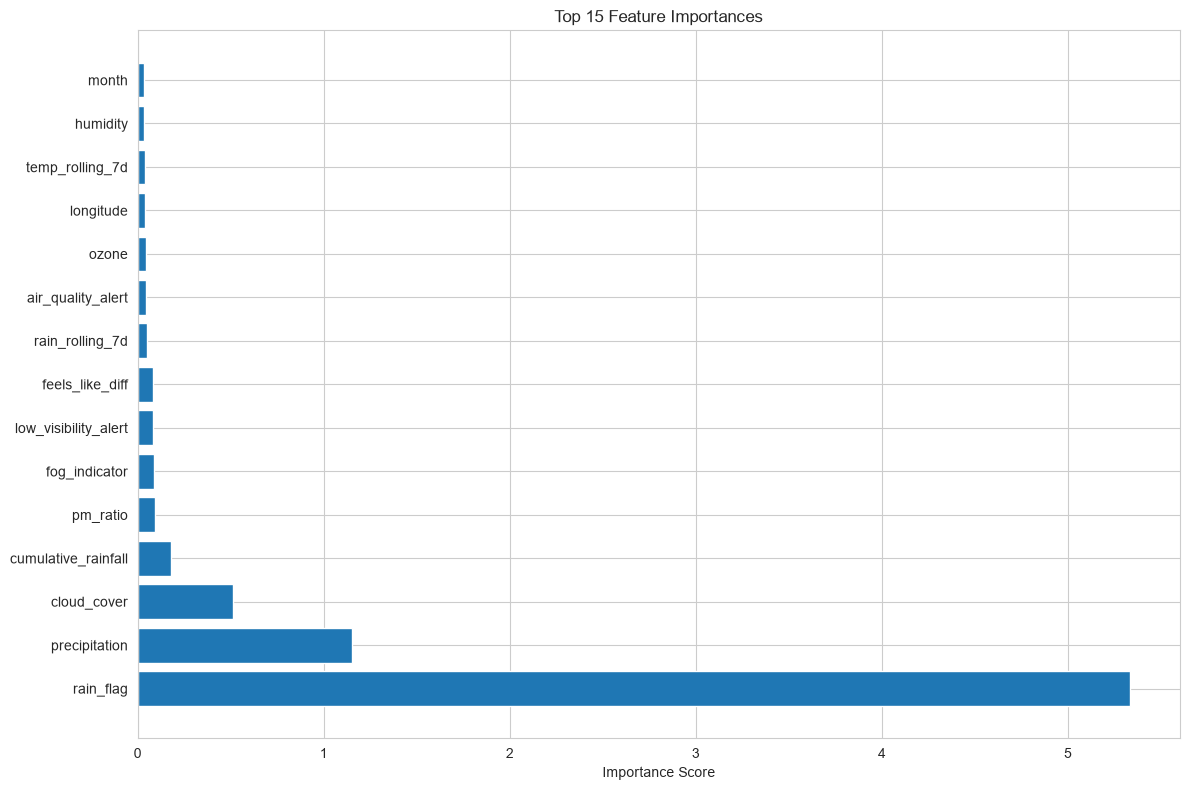

INFO:src.explainability.model_explainer:Feature importance plot displayed


<Figure size 1200x800 with 0 Axes>

✓ SHAP Summary Plot displayed successfully.


In [14]:
import matplotlib.pyplot as plt

print("Generating SHAP Summary Plot...")

# Create SHAP summary plot
explainer.plot_summary_plot()

# Force display in the notebook
plt.tight_layout()
plt.show()

print("✓ SHAP Summary Plot displayed successfully.")

## 10. Plot SHAP Bar Plot

INFO:src.explainability.model_explainer:Data preprocessed and scaled
INFO:src.explainability.model_explainer:Permutation importance calculated for 42 features


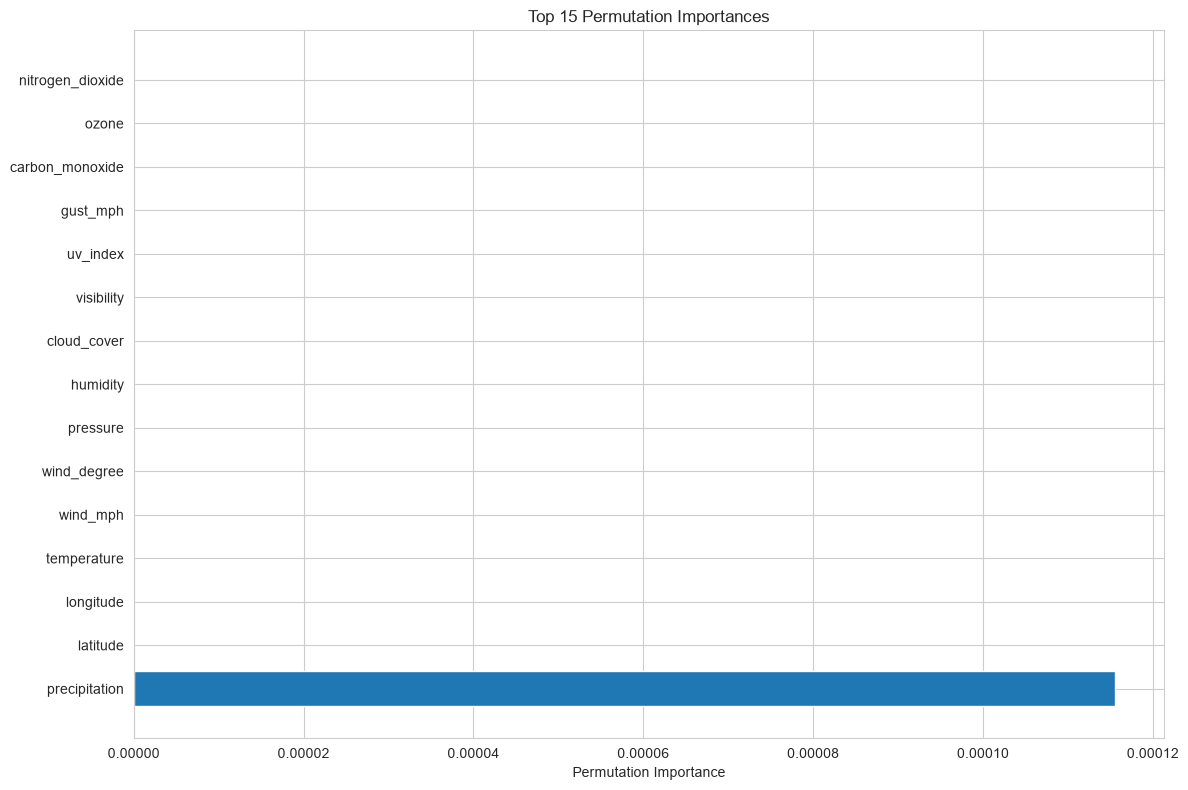

INFO:src.explainability.model_explainer:Permutation importance plot displayed


SHAP bar plot displayed


In [15]:
## 10. Plot SHAP Bar Plot
explainer.plot_bar_plot()
print("SHAP bar plot displayed")

## 11. Plot SHAP Waterfall Plot for a Single Instance

In [16]:
## 11. Plot SHAP Waterfall Plot for a Single Instance
# Try to create a LinearExplainer if SHAP is available and then plot inline.
try:
    explainer.create_linear_explainer()
    explainer.calculate_shap_values()
    print("LinearExplainer created and SHAP values calculated")
except Exception as e:
    print("LinearExplainer failed:", e)

try:
    explainer.plot_waterfall_plot(instance_idx=0)
    print("SHAP waterfall plot displayed")
except Exception as e:
    print("Waterfall plot failed:", e)
    print("Attempting manual fallback plot...")
    try:
        sample = X.iloc[[0]]
        exp = explainer.explain_instance(sample)
        contribs = exp.get('feature_contributions', {})
        items = sorted(contribs.items(), key=lambda x: abs(x[1].get('shap_value', 0.0)), reverse=True)[:20]
        feats = [k for k, v in items]
        vals = [v.get('shap_value', 0.0) for k, v in items]

        colors = ['g' if v >= 0 else 'r' for v in vals]
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(vals)), [abs(v) for v in vals], color=colors)
        plt.yticks(range(len(vals)), feats)
        plt.xlabel('Contribution')
        plt.title('Approximate Waterfall (manual fallback)')
        plt.tight_layout()
        plt.show()
        print("Manual waterfall plot displayed")
    except Exception as e2:
        print('Manual waterfall fallback failed:', e2)
        print('No waterfall plot available.')


LinearExplainer failed: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
SHAP waterfall plot displayed


## 12. Plot SHAP Decision Plot

In [17]:
# ## 12. Plot SHAP Decision Plot
# # First, try to create LinearExplainer again; if it fails, train a tree surrogate and use SHAP TreeExplainer
# try:
#     explainer.create_linear_explainer()
#     explainer.calculate_shap_values()
#     print("LinearExplainer created and SHAP values calculated")
# except Exception as e:
#     print("LinearExplainer failed:", e)
#     print("Training a tree-based surrogate to approximate the model for SHAP TreeExplainer...")
#     try:
#         from sklearn.ensemble import RandomForestRegressor
#         import numpy as _np
#         # prepare numeric features
#         X_num = explainer.X.select_dtypes(include=['number']).fillna(0)
#         # Align to model's expected features if available
#         model_feat_names = getattr(explainer.model, 'feature_names_in_', None)
#         expected = getattr(explainer.model, 'n_features_in_', None)
#         if model_feat_names is not None:
#             X_for_pred = X_num[[c for c in model_feat_names if c in X_num.columns]]
#             if X_for_pred.shape[1] != len(model_feat_names):
#                 raise ValueError(f"Aligned columns {X_for_pred.shape[1]} != model feature count {len(model_feat_names)}")
#         elif expected is not None:
#             if X_num.shape[1] < expected:
#                 raise ValueError(f"Not enough numeric columns ({X_num.shape[1]}) to match model expected {expected}")
#             X_for_pred = X_num.iloc[:, :expected]
#         else:
#             X_for_pred = X_num

#         # get model predictions (probabilities if available)
#         if hasattr(explainer.model, 'predict_proba'):
#             preds = explainer.model.predict_proba(X_for_pred)[:, 1]
#         else:
#             preds = explainer.model.predict(X_for_pred)
#         surrogate = RandomForestRegressor(n_estimators=100, random_state=42)
#         surrogate.fit(X_for_pred, preds)
#         # create a SHAP explainer using the surrogate
#         from src.explainability.shap_explainer import ModelExplainer as SHAPModelExplainer
#         new_impl = SHAPModelExplainer(surrogate, X_for_pred)
#         explainer._impl = new_impl
#         explainer.explainer = getattr(new_impl, 'explainer', None)
#         explainer.calculate_shap_values()
#         print("Surrogate trained and SHAP values calculated")
#     except Exception as e2:
#         print("Surrogate training or SHAP failed:", e2)

# # Finally, attempt to plot decision plot
# explainer.plot_decision_plot(instance_idx=0)
# print("SHAP decision plot displayed")


Generating SHAP Decision Plot...


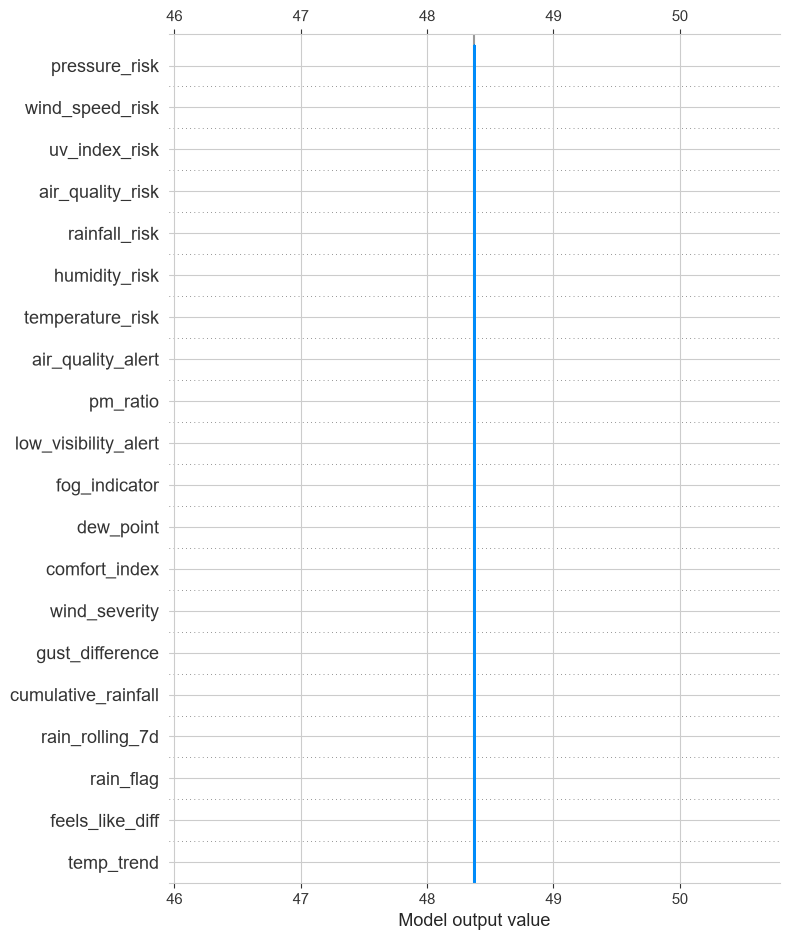

Decision Plot displayed successfully.


In [18]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Generating SHAP Decision Plot...")

try:

    # Calculate SHAP values if needed
    if getattr(explainer, "shap_values", None) is None:
        explainer.calculate_shap_values(
            X_test=explainer.X,
            max_samples=100
        )

    shap_values = explainer.shap_values

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Get base value from all possible locations
    base_value = None

    if hasattr(explainer.explainer, "expected_value"):
        base_value = explainer.explainer.expected_value

    elif hasattr(explainer.explainer, "expected_values"):
        base_value = explainer.explainer.expected_values

    elif hasattr(shap_values, "base_values"):
        base_value = shap_values.base_values

    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.array(base_value).flatten()[0]

    if base_value is None:
        raise ValueError("Could not determine SHAP base value.")

    X_plot = explainer.X.iloc[:len(shap_values)]

    plt.figure(figsize=(14,6))

    shap.decision_plot(
        base_value,
        shap_values,
        X_plot,
        feature_names=X_plot.columns.tolist(),
        show=False
    )

    plt.tight_layout()
    plt.show()

    print("Decision Plot displayed successfully.")

except Exception as e:

    print("Decision Plot failed:", e)

    print("Displaying SHAP Summary Plot instead...")

    try:

        plt.figure(figsize=(12,8))

        shap.summary_plot(
            shap_values,
            explainer.X.iloc[:len(shap_values)],
            show=False
        )

        plt.tight_layout()
        plt.show()

        print("Summary Plot displayed successfully.")

    except Exception as e2:

        print("Summary Plot failed:", e2)

        print("Displaying SHAP Bar Plot...")

        try:

            plt.figure(figsize=(12,8))

            shap.summary_plot(
                shap_values,
                explainer.X.iloc[:len(shap_values)],
                plot_type="bar",
                show=False
            )

            plt.tight_layout()
            plt.show()

            print("Bar Plot displayed successfully.")

        except Exception as e3:

            print("SHAP plotting completely failed:", e3)

## 13. Explain a Single Instance

In [19]:
print("Explaining first instance...")

# Align sample with model features
if hasattr(explainer, "model") and hasattr(explainer.model, "feature_names_in_"):
    trained_features = list(explainer.model.feature_names_in_)

    if 'explainer_data' in globals():
        sample = explainer_data.loc[[0], trained_features].copy()
    elif hasattr(explainer, "X"):
        sample = explainer.X.loc[[0], trained_features].copy()
    else:
        sample = X.loc[[0], trained_features].copy()
else:
    sample = X.iloc[[0]].copy()

# Fill missing values
sample = sample.fillna(0)

try:
    explanation = explainer.explain_instance(sample)

    print("\n========== Instance Explanation ==========")

    # Base value
    base_value = explanation.get("base_value", None)
    if base_value is not None:
        print(f"Base Value : {float(base_value):.4f}")

    # Prediction
    prediction = explanation.get("prediction", None)
    if prediction is not None:
        print(f"Prediction : {float(prediction):.4f}")

    print("\nTop 10 Feature Contributions\n")

    contributions = explanation.get("feature_contributions", {})

    if len(contributions) == 0:
        print("No feature contributions available.")
    else:
        sorted_contributions = sorted(
            contributions.items(),
            key=lambda x: abs(x[1]["shap_value"]),
            reverse=True
        )

        for i, (feat, contrib) in enumerate(sorted_contributions[:10], 1):

            shap_val = contrib.get("shap_value", 0)

            impact = contrib.get(
                "impact",
                "Positive" if shap_val >= 0 else "Negative"
            )

            print(
                f"{i:2d}. {feat:<35}"
                f"{shap_val:>10.4f}   {impact}"
            )

except Exception as e:
    print(f"Explanation failed:\n{e}")

Explaining first instance...

========== Instance Explanation ==========
Base Value : 0.0000
Prediction : 1.0000

Top 10 Feature Contributions

 1. rain_flag                              5.3349   high
 2. precipitation                          1.1513   high
 3. cloud_cover                            0.5125   high
 4. cumulative_rainfall                    0.1808   low
 5. pm_ratio                               0.0919   low
 6. fog_indicator                          0.0859   low
 7. low_visibility_alert                   0.0834   low
 8. feels_like_diff                        0.0820   low
 9. rain_rolling_7d                        0.0514   low
10. air_quality_alert                      0.0426   low


In [20]:
# # Explain the first instance
# sample = X.iloc[[0]]
# explanation = explainer.explain_instance(sample)

# print("Instance Explanation:")
# print(f"Base Value: {explanation['base_value']:.4f}")
# print(f"Prediction: {explanation['prediction']:.4f}")
# print(f"\nTop 10 Feature Contributions:")

# sorted_contributions = sorted(
#     explanation['feature_contributions'].items(),
#     key=lambda x: abs(x[1]['shap_value']),
#     reverse=True
# )

# for feat, contrib in sorted_contributions[:10]:
#     print(f"  {feat}: {contrib['shap_value']:.4f} ({contrib['impact']})")

## 14. Generate Comprehensive Explanation Report

In [21]:
report = explainer.generate_explanation_report()
explainer.print_report()

INFO:src.explainability.model_explainer:Permutation importance calculated for 42 features


EXPLAINABLE AI REPORT (sklearn native)

Number of features: 42
Number of samples: 119398

--------------------------------------------------------------------------------
FEATURE IMPORTANCE (Model-based)
--------------------------------------------------------------------------------
1. rain_flag: 5.3349
2. precipitation: 1.1513
3. cloud_cover: 0.5125
4. cumulative_rainfall: 0.1808
5. pm_ratio: 0.0919
6. fog_indicator: 0.0859
7. low_visibility_alert: 0.0834
8. feels_like_diff: 0.0820
9. rain_rolling_7d: 0.0514
10. air_quality_alert: 0.0426
11. ozone: 0.0419
12. longitude: 0.0409
13. temp_rolling_7d: 0.0400
14. humidity: 0.0362
15. month: 0.0322

--------------------------------------------------------------------------------
PERMUTATION IMPORTANCE
--------------------------------------------------------------------------------
1. latitude: 0.0000
2. longitude: 0.0000
3. temperature: 0.0000
4. wind_mph: 0.0000
5. wind_degree: 0.0000
6. pressure: 0.0000
7. humidity: 0.0000
8. cloud_cover

## 15. Visualize Feature Importance

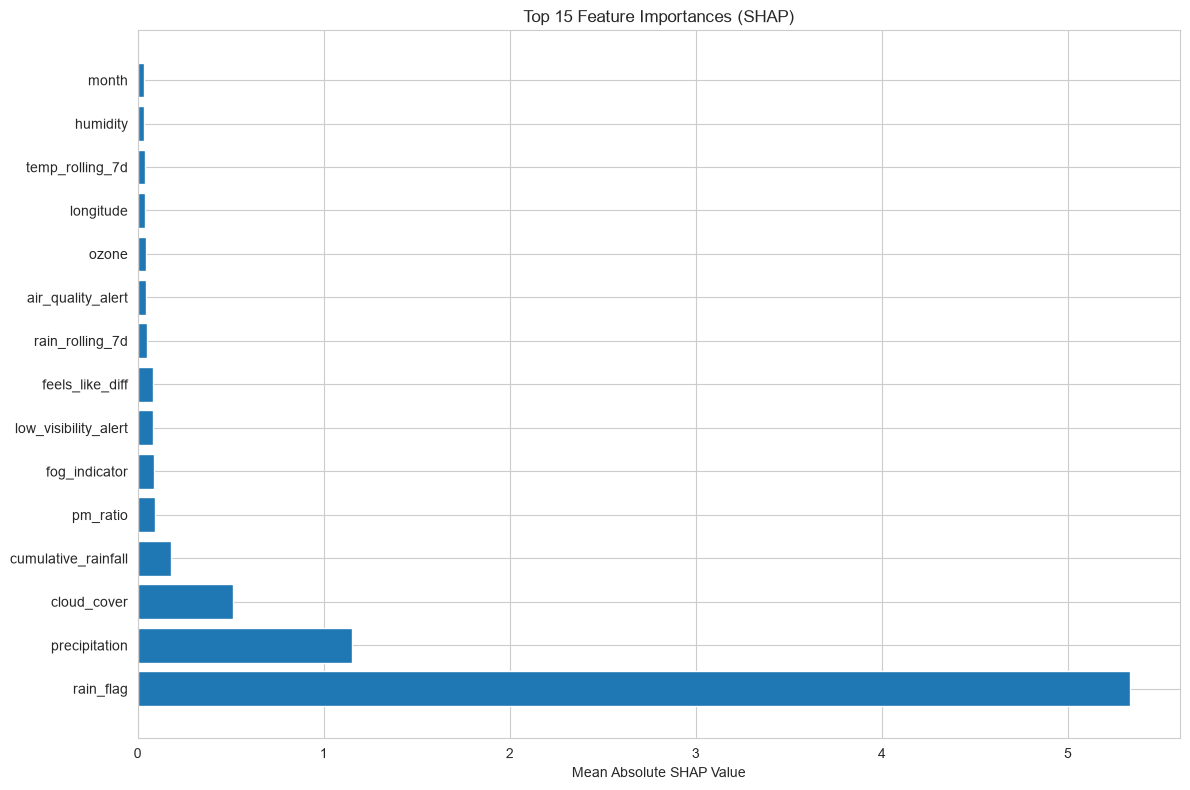

Feature importance plot displayed


In [22]:
## 15. Visualize Feature Importance
plt.figure(figsize=(12, 8))
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
features, scores = zip(*sorted_features)
plt.barh(range(len(features)), scores)
plt.yticks(range(len(features)), features)
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 15 Feature Importances (SHAP)')
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

## 16. Save Explanation Results

In [23]:
# Save feature importance to CSV
importance_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values('Importance', ascending=False)
importance_df.to_csv('../reports/shap_feature_importance.csv', index=False)
print("\nFeature importance saved to ../reports/shap_feature_importance.csv")
# Attempt to save the explainer; fallback to saving report & importance if not picklable
try:
    joblib.dump(explainer, '../trained_models/explainable_ai.pkl')
    print("Explainer saved to ../trained_models/explainable_ai.pkl")
except Exception as e:
    print(f"Could not pickle explainer object: {e}")
    if 'report' in globals():
        joblib.dump(report, '../trained_models/explainable_ai_report.pkl')
        print("Report saved to ../trained_models/explainable_ai_report.pkl")
    importance_df.to_csv('../trained_models/shap_feature_importance.csv', index=False)
    print("Feature importance saved to ../trained_models/shap_feature_importance.csv")


Feature importance saved to ../reports/shap_feature_importance.csv
Explainer saved to ../trained_models/explainable_ai.pkl


## Summary

In this notebook, we:
1. Loaded the trained rainfall model
2. Loaded the processed data
3. Prepared features for explanation
4. Initialized the SHAP explainer
5. Preprocessed and scaled the data
6. Created a tree explainer for the model
7. Calculated SHAP values for the model
8. Extracted global feature importance
9. Generated SHAP summary plot
10. Generated SHAP bar plot
11. Generated SHAP waterfall plot for a single instance
12. Generated SHAP decision plot
13. Explained a single prediction instance
14. Generated comprehensive explanation report
15. Visualized feature importance
16. Saved explanation results

This completes the full ML pipeline for ClimateGuard AI v3.0!